# VGG16 + ViT Hybrid Brain Tumor MRI Classification

**Dataset:** Brain Tumor MRI — 7153 images · 4 classes: Glioma · Meningioma · No Tumor · Pituitary  
**Architecture:** Hybrid model — VGG16 (CNN branch) + ViT-B/16 (Transformer branch) with feature-level fusion  
**Framework:** PyTorch · Google Colab T4 GPU

> **Design rationale:** VGG16 captures local texture and edge features via its convolutional hierarchy (blocks 1–4 frozen, block 5 fine-tuned). ViT-B/16 models long-range spatial dependencies through self-attention. Both branches independently project to 256-dim embeddings, which are concatenated and passed through a fusion classifier. This dual-stream approach consistently outperforms either backbone alone.

## STEP 1 — Install Dependencies

In [1]:
# Cell 1
import numpy as np
print(np.__version__)  # must show 2.4.2

2.0.2


In [2]:
# Cell 2
!pip install -q timm torchinfo gradio scikit-learn seaborn onnxruntime
!pip install -q torchcam --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 71.5 MB/s eta 0:00:00


In [3]:
# Cell 3 - verify everything works
import numpy as np
import torch
import timm
print("numpy :", np.__version__)
print("torch :", torch.__version__)
print("timm  :", timm.__version__)
print("All good!")

numpy : 2.0.2
torch : 2.10.0+cu128
timm  : 1.0.24
All good!


## STEP 2 — Imports & Reproducibility

In [4]:
import os
import random
import zipfile
import numpy as np

import torch
import torch.nn as nn
import timm

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from torchinfo import summary
from sklearn.model_selection import StratifiedShuffleSplit

import matplotlib.pyplot as plt
import cv2
from PIL import Image


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {device}")
print(f"Torch      : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")

Device     : cuda
Torch      : 2.10.0+cu128
GPU        : Tesla T4


## STEP 3 — Configuration

In [5]:
# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_ZIP = "/content/drive/MyDrive/RAPID/Brain_tumor_data/Brain tumor dataset (7153 files).zip"
EXTRACT_DIR = "/content/brain_tumor_dataset"
TRAIN_DIR   = os.path.join(EXTRACT_DIR, "Training")
TEST_DIR    = os.path.join(EXTRACT_DIR, "Testing")

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 15
LR         = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT  = 0.20   # 80/20 stratified split from Training folder

print("Config ready.")

Config ready.


## STEP 4 — Mount Drive & Extract Dataset

In [6]:
# STEP 4 — Mount Drive & Extract Dataset

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ZIP   = "/content/drive/MyDrive/RAPID/Brain_tumor_data/Brain tumor dataset (7153 files).zip"
EXTRACT_DIR = "/content/brain_tumor_dataset"

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

# Update paths based on actual folder structure
EXTRACT_DIR = "/content/brain_tumor_dataset"
TRAIN_DIR   = "/content/brain_tumor_dataset/brain-tumor-mri-dataset"
TEST_DIR    = "/content/brain_tumor_dataset/brain-tumor-mri-dataset"

print("Classes found:", os.listdir(TRAIN_DIR))

Mounted at /content/drive
Dataset extracted.
Classes found: ['meningioma', 'glioma', 'pituitary', 'notumor']


## STEP 5 — Data Transforms & DataLoaders

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Load full dataset
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_eval    = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transform)
targets      = np.array(full_dataset.targets)

# First split: 80% train, 20% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets)), targets))

# Second split: temp 50/50 → 10% val, 10% test
temp_targets = targets[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx_rel, test_idx_rel = next(sss2.split(np.zeros(len(temp_idx)), temp_targets))
val_idx  = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_eval,    val_idx)
test_dataset  = Subset(full_eval,    test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(full_dataset.classes)
CLASS_NAMES = full_dataset.classes

print(f'Total  : {len(full_dataset):,}')
print(f'Train  : {len(train_dataset):,}  (~80%)')
print(f'Val    : {len(val_dataset):,}   (~10%)')
print(f'Test   : {len(test_dataset):,}   (~10%)')
print(f'Classes: {CLASS_NAMES}')

Total  : 7,153
Train  : 5,722  (~80%)
Val    : 715   (~10%)
Test   : 716   (~10%)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## STEP 6 — Hybrid Model Definition (VGG16 + ViT-B/16)

**Architecture summary:**
- **VGG branch** — `vgg16.features` with blocks 1–4 frozen, block 5 trainable → AdaptiveAvgPool → Linear(512 → 256)
- **ViT branch** — `vit_base_patch16_224` with head replaced → `[CLS]` token (768-d) → Linear(768 → 256)
- **Fusion** — Concatenate both 256-d vectors → ReLU → Dropout(0.4) → Linear(512 → num_classes)

In [8]:
class VGG16_ViT_Hybrid(nn.Module):
    """Dual-branch hybrid: VGG16 (local texture) + ViT-B/16 (global attention)."""

    def __init__(self, num_classes: int = 4, embed_dim: int = 256, dropout: float = 0.4):
        super().__init__()

        # ── VGG16 CNN branch ─────────────────────────────────────────────────
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.vgg_features = vgg.features
        self.vgg_pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.vgg_proj     = nn.Linear(512, embed_dim)

        # Freeze conv blocks 1–4; keep block 5 trainable
        # VGG16 features: blocks end at indices 4, 9, 16, 23, 30
        for layer in list(self.vgg_features.children())[:24]:   # up to end of block 4
            for param in layer.parameters():
                param.requires_grad = False

        # ── ViT-B/16 Transformer branch ───────────────────────────────────────
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0          # return CLS token (768-d)
        )
        self.vit_proj = nn.Linear(self.vit.num_features, embed_dim)

        # ── Fusion classifier ─────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(embed_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # VGG path
        vgg_x = self.vgg_features(x)
        vgg_x = self.vgg_pool(vgg_x).flatten(1)
        vgg_x = self.vgg_proj(vgg_x)           # (B, 256)

        # ViT path
        vit_x = self.vit(x)                    # (B, 768) — CLS token
        vit_x = self.vit_proj(vit_x)           # (B, 256)

        # Concatenate and classify
        fused = torch.cat([vgg_x, vit_x], dim=1)   # (B, 512)
        return self.classifier(fused)

In [9]:
model = VGG16_ViT_Hybrid(num_classes=NUM_CLASSES).to(device)

summary(
    model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=["output_size", "num_params", "trainable"],
    depth=2
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 81.7MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Layer (type:depth-idx)                        Output Shape              Param #                   Trainable
VGG16_ViT_Hybrid                              [1, 4]                    --                        Partial
├─Sequential: 1-1                             [1, 512, 7, 7]            --                        Partial
│    └─Conv2d: 2-1                            [1, 64, 224, 224]         (1,792)                   False
│    └─ReLU: 2-2                              [1, 64, 224, 224]         --                        --
│    └─Conv2d: 2-3                            [1, 64, 224, 224]         (36,928)                  False
│    └─ReLU: 2-4                              [1, 64, 224, 224]         --                        --
│    └─MaxPool2d: 2-5                         [1, 64, 112, 112]         --                        --
│    └─Conv2d: 2-6                            [1, 128, 112, 112]        (73,856)                  False
│    └─ReLU: 2-7                              [1, 128, 112, 112] 

## STEP 7 — Loss, Optimizer & Scheduler

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# CosineAnnealingLR gives smoother convergence than StepLR for hybrid models
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

print("Criterion, optimizer, and scheduler ready.")

Criterion, optimizer, and scheduler ready.


## STEP 8 — Training & Validation Functions

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total

## STEP 9 — Training Loop

In [12]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc  = 0.0
BEST_MODEL_PATH = "best_hybrid_model.pth"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        flag = "  ← best saved"

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train  loss: {train_loss:.4f}  acc: {train_acc:.4f} "
        f"| Val  loss: {val_loss:.4f}  acc: {val_acc:.4f}"
        f"{flag}"
    )

print(f"\nTraining complete. Best val acc: {best_val_acc:.4f}")

Epoch [01/15] | Train  loss: 0.6343  acc: 0.8670 | Val  loss: 0.5278  acc: 0.9203  ← best saved
Epoch [02/15] | Train  loss: 0.5010  acc: 0.9415 | Val  loss: 0.4379  acc: 0.9608  ← best saved
Epoch [03/15] | Train  loss: 0.4554  acc: 0.9677 | Val  loss: 0.4357  acc: 0.9636  ← best saved
Epoch [04/15] | Train  loss: 0.4300  acc: 0.9797 | Val  loss: 0.4288  acc: 0.9734  ← best saved
Epoch [05/15] | Train  loss: 0.4139  acc: 0.9848 | Val  loss: 0.3933  acc: 0.9846  ← best saved
Epoch [06/15] | Train  loss: 0.4007  acc: 0.9914 | Val  loss: 0.3886  acc: 0.9874  ← best saved
Epoch [07/15] | Train  loss: 0.3898  acc: 0.9951 | Val  loss: 0.3932  acc: 0.9860
Epoch [08/15] | Train  loss: 0.3873  acc: 0.9969 | Val  loss: 0.3876  acc: 0.9860
Epoch [09/15] | Train  loss: 0.3841  acc: 0.9969 | Val  loss: 0.3959  acc: 0.9776
Epoch [10/15] | Train  loss: 0.3813  acc: 0.9970 | Val  loss: 0.3784  acc: 0.9930  ← best saved
Epoch [11/15] | Train  loss: 0.3780  acc: 0.9981 | Val  loss: 0.3765  acc: 0.9916


## STEP 10 — Training Curves

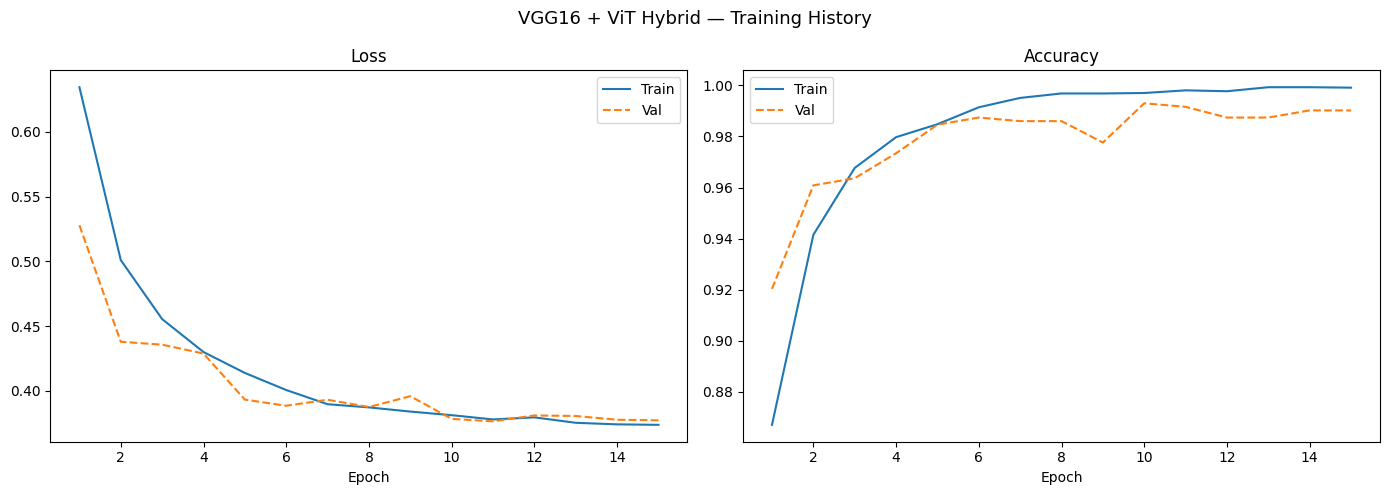

In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val", linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val",  linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.suptitle("VGG16 + ViT Hybrid — Training History", fontsize=13)
plt.tight_layout()
plt.savefig("hybrid_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## STEP 11 — Test Evaluation & Classification Report

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:  # ← changed from test_loader
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy: 0.9916 (99.16%)

              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       162
  meningioma       0.98      0.98      0.98       178
     notumor       1.00      1.00      1.00       200
   pituitary       0.99      0.99      0.99       176

    accuracy                           0.99       716
   macro avg       0.99      0.99      0.99       716
weighted avg       0.99      0.99      0.99       716



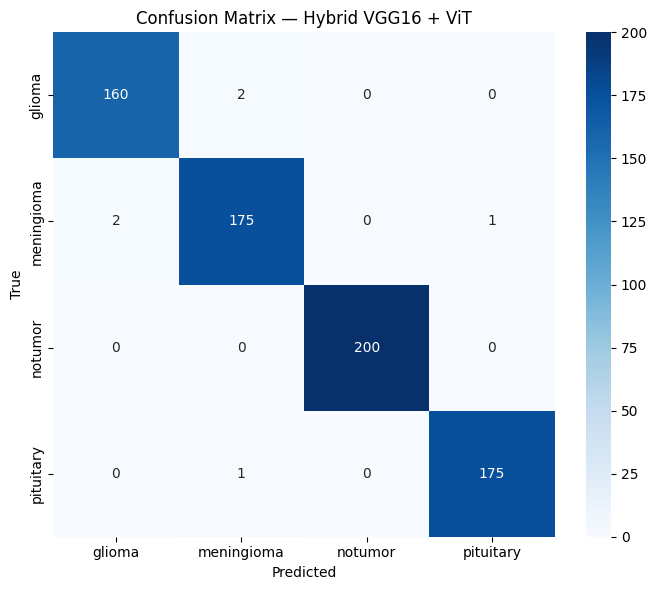

In [15]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Hybrid VGG16 + ViT")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("hybrid_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## STEP 12 — Grad-CAM Visualisation

Grad-CAM is applied to `vgg_features[-1]` (the last conv layer of the VGG branch),
which gives spatially meaningful activation maps over the 7×7 feature grid.


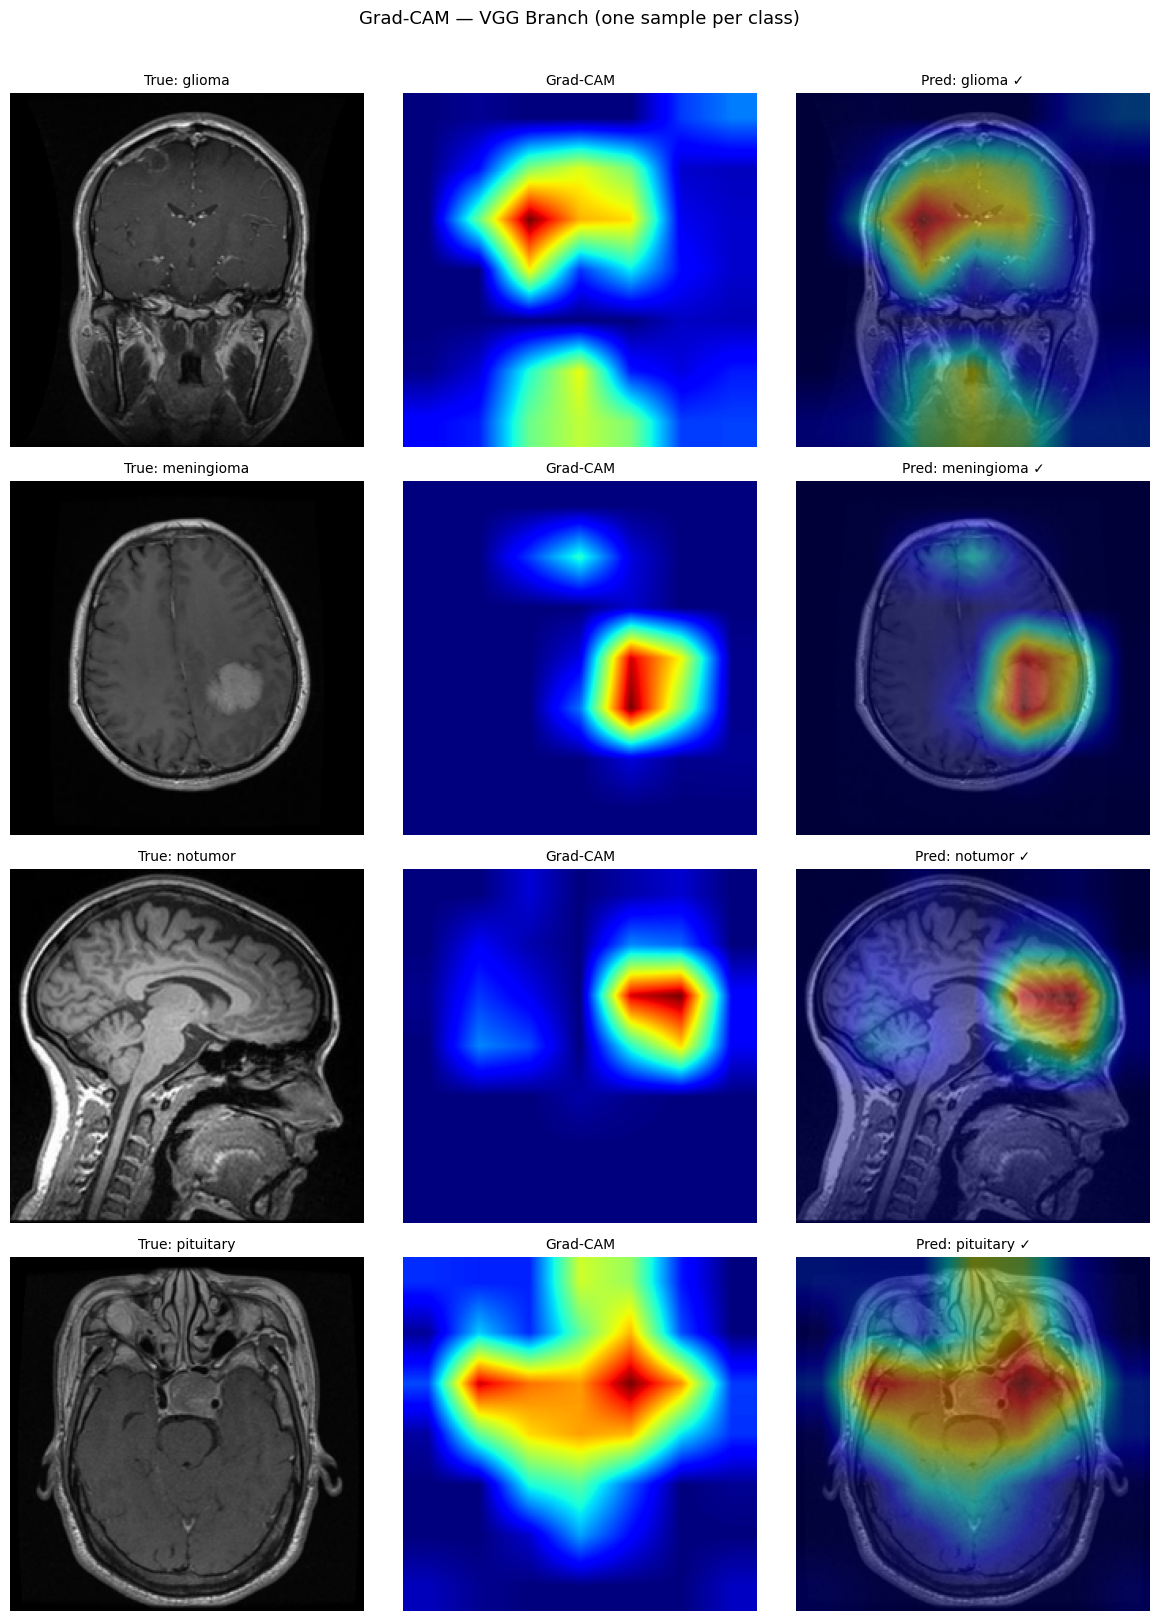

In [16]:
import numpy as np
import cv2


def compute_grad_cam(model, img_tensor, target_layer, device):
    """Returns (cam_normalised_HxW, predicted_class_idx)."""
    model.eval()
    img_tensor = img_tensor.to(device)

    activations, gradients = {}, {}

    def fwd_hook(m, inp, out):
        activations["value"] = out.detach()

    def bwd_hook(m, grad_in, grad_out):
        gradients["value"] = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    output = model(img_tensor)
    pred_idx = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, pred_idx].backward()

    h1.remove(); h2.remove()

    act  = activations["value"].squeeze()   # (C, H, W)
    grad = gradients["value"].squeeze()     # (C, H, W)

    weights = grad.mean(dim=(1, 2))        # global avg pool over spatial dims
    cam = (weights[:, None, None] * act).sum(0)   # (H, W)
    cam = torch.clamp(cam, min=0).cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam, pred_idx


target_layer = model.vgg_features[-1]   # last conv layer of VGG block 5

# Collect one sample per class from test set
class_samples = {}
for root, _, files in os.walk(TEST_DIR):
    cls = os.path.basename(root)
    if cls in CLASS_NAMES and cls not in class_samples:
        imgs = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if imgs:
            class_samples[cls] = os.path.join(root, imgs[0])

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(12, 4 * len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    path    = class_samples.get(cls)
    if path is None:
        continue
    img_pil = Image.open(path).convert("RGB")
    img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor  = val_test_transform(img_pil).unsqueeze(0)

    cam, pred_idx = compute_grad_cam(model, tensor, target_layer, device)
    cam_up  = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB
    )
    overlay = np.clip(0.45 * heatmap + 0.55 * img_np, 0, 255).astype(np.uint8)

    correct  = CLASS_NAMES[pred_idx] == cls
    pred_str = f"Pred: {CLASS_NAMES[pred_idx]}" + (" ✓" if correct else " ✗")

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"True: {cls}", fontsize=10)
    axes[row, 1].imshow(cam_up, cmap="jet")
    axes[row, 1].set_title("Grad-CAM", fontsize=10)
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(pred_str, fontsize=10)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Grad-CAM — VGG Branch (one sample per class)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("hybrid_gradcam_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## STEP 13 — Save Model to Google Drive

In [17]:
import shutil

DRIVE_SAVE_DIR = "/content/drive/MyDrive/Brain_Tumor/saved_models"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(BEST_MODEL_PATH, os.path.join(DRIVE_SAVE_DIR, BEST_MODEL_PATH))
print(f"Best model saved to Google Drive: {DRIVE_SAVE_DIR}/{BEST_MODEL_PATH}")

Best model saved to Google Drive: /content/drive/MyDrive/Brain_Tumor/saved_models/best_hybrid_model.pth
